# Object Reference Count

The object reference count tells, what's the number of variables/labels are currently pointing to the `this` object.

To count object's `refcnt` we can use many methods, as following:

<br>

---

<br>

### 1. Standard Approach `sys.getrefcount(object)`

You pass the object directly or its variable/label name directly to this function.

In [1]:
import sys

obj_lst = [1, 2, 3, 4]

print(f"obj_refcnt: {sys.getrefcount(obj_lst)}")

obj_refcnt: 2


> ⚠️ Important Caveat: `sys.getrefcount()` always returns a value higher than expected. This occurs because passing the object into the function temporarily creates an extra reference to it. To get the actual count, subtract 1 from the result.

<br>

---

<br>

### 2. Alternative Approach: `ctypes` (No Extra Reference)

If you need to find the exact count without triggering an artificial increment, bypass the standard argument-passing mechanism using the ctypes module to read the value directly from memory.

In [ ]:
import ctypes

a = [1, 2]

# get count
count = ctypes.c_long.from_address(id(a)).value

print(f"obj_refcnt: {count}")

obj_refcnt: 1


### Verify ctypes by adding one more `ref` to `a:List`

In [ ]:
b = obj_lst               # now list object has two ref's, original a and b pointing to it

count = ctypes.c_long.from_address(id(obj_lst)).value

print(f"obj_refcnt: {count}")

obj_refcnt: 2


### Memory View

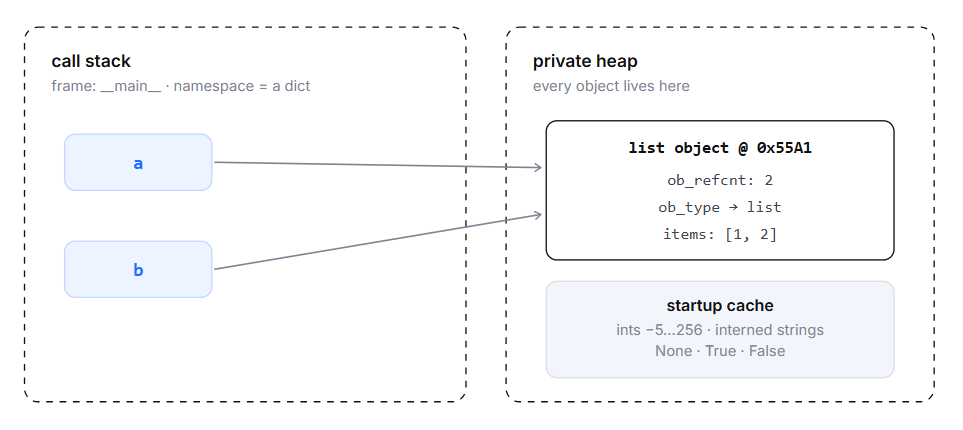

<br>

---

<br>

# Class object_refcnt

Even `ctypes` produce `obj__refcnt` different for class object, so it's worth pointing to clarify it over here. We will see through examples and verify why we are having extra `obj_refcnt` when we have limited number of objects defined. 

In [8]:
class Person:
    # constructor
    def __init__(self, name):
        self.name = name

    # setter
    def setter(self, name):
        if self.name != name:
            self.name = name

    # getter
    def get(self):
        return self.name

p1 = Person("Saqib Bedar")
p2 = p1             # now p2 is pointing to class instance object exactly where p1 is pointing currently. (single obj two refcnt)

### Verify `p1` and `p2`

Check if both are pointing or having ref to same object.

In [9]:
print(f"p1.__dict__: {p1.__dict__}")
print(f"p2.__dict__: {p2.__dict__}")

p1.__dict__: {'name': 'Saqib Bedar'}
p2.__dict__: {'name': 'Saqib Bedar'}


### Adding new arbitrary attribute

Add new arbitrary attribute on any of variable/label. Note, in Python there is no variable, its a dictionary key that is having ref to the object so I am using variable/label naming constantly.

Here what I am trying to say? See, when we add any new attribute on `p1` or `p2` because we have single `__ dict __` and both `p1` and `p2` are pointing to it. Attribute will sit on `__ dict __` of `current__obj` and both will reference it. Any change on `this` object will be reflecting in both variables on log.  

In [11]:
# define arbitrary attribute on p1
p1.age = 10

# verify change on p2
print(p2.__dict__)

{'name': 'Saqib Bedar', 'age': 10}


# Count `class` obj ref

In [14]:
import ctypes

p1_refcnt = ctypes.c_long.from_address(id(p1)).value
p2_refcnt = ctypes.c_long.from_address(id(p2)).value
class_refcnt = ctypes.c_long.from_address(id(Person)).value

print(f"p1_refcnt: {p1_refcnt}")
print(f"p2_refcnt: {p2_refcnt}")
print(f"class_refcnt: {class_refcnt}")

p1_refcnt: 3
p2_refcnt: 3
class_refcnt: 5


> 🪧 Notice: for `p1_refcnt` and `p2_refcnt` we have exactly two references as we discussed above, one object is pointed by 2 variables/labels. But, class_refcnt is different, because the Python interpreter and your own code maintain internal references to the class object itself to keep the runtime functioning.

Explanation: When you check the reference count of a class (like `Person`), you are not counting instances of that class (like `p1`). Instead, you are counting how many places in the Python environment currently hold a pointer to the class definition object.

### Verify `class` references

In [17]:
# garbage collector
import gc

# gc.get_referrers() -> List
for ref in gc.get_referrers(Person):
    print(f"Referrer type: {type(ref)}")

print(f"\nTotal refs: {len(gc.get_referrers(Person))}")

Referrer type: <class 'dict'>
Referrer type: <class 'tuple'>
Referrer type: <class 'getset_descriptor'>
Referrer type: <class 'getset_descriptor'>
Referrer type: <class '__main__.Person'>

Total refs: 5
